# Netflix Content Clustering with KMeans
This notebook uses KMeans clustering to group Netflix titles by genre, rating, and duration.
It includes an interactive recommender that finds similar titles based on your input.

## 1. Imports & Setup

In [33]:
import kagglehub
import pandas as pd
import numpy as np
import os
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler, MultiLabelBinarizer
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import cosine_similarity

In [34]:
import warnings
warnings.filterwarnings('ignore')

## 2. Load Data

In [35]:
path = kagglehub.dataset_download("shivamb/netflix-shows")
print("Path to dataset files:", path)

for file in os.listdir(path):
    if file.endswith(".csv"):
        csv_path = os.path.join(path, file)
        break

df = pd.read_csv(csv_path)
df.head()

Using Colab cache for faster access to the 'netflix-shows' dataset.
Path to dataset files: /kaggle/input/netflix-shows


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


## 3. Feature Engineering

### 3a. Genre Encoding

In [36]:
df['genre_list'] = df['listed_in'].str.split(', ')

mlb = MultiLabelBinarizer()
genre_dummies = pd.DataFrame(
    mlb.fit_transform(df['genre_list']),
    columns=mlb.classes_,
    index=df.index
)
genre_dummies.head()

,Action & Adventure,Anime Features,Anime Series,British TV Shows,Children & Family Movies,Classic & Cult TV,Classic Movies,Comedies,Crime TV Shows,Cult Movies,...,TV Action & Adventure,TV Comedies,TV Dramas,TV Horror,TV Mysteries,TV Sci-Fi & Fantasy,TV Shows,TV Thrillers,Teen TV Shows,Thrillers
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,1,0,0,0,0,0
2,0,0,0,0,0,0,0,0,1,0,...,1,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0


### 3b. Duration Normalization
> **Assumption:** 1 Season ≈ 10 episodes × 45 min = 450 minutes

In [37]:
df['duration'] = df['duration'].astype(str)
df['duration_num'] = df['duration'].str.extract('(\d+)').astype(float)
df['duration_minutes'] = df.apply(
    lambda row: row['duration_num'] * 450 if "Season" in row['duration'] else row['duration_num'],
    axis=1)
df['duration_minutes'] = df['duration_minutes'].fillna(df['duration_minutes'].mean())
df[['title', 'duration', 'duration_minutes']].head()

,title,duration,duration_minutes
0,Dick Johnson Is Dead,90 min,90.0
1,Blood & Water,2 Seasons,900.0
2,Ganglands,1 Season,450.0
3,Jailbirds New Orleans,1 Season,450.0
4,Kota Factory,2 Seasons,900.0


### 3c. Rating Encoding (One-Hot)

In [38]:
rating_dummies = pd.get_dummies(df['rating'], prefix='rating')
rating_dummies.head()

,rating_66 min,rating_74 min,rating_84 min,rating_G,rating_NC-17,rating_NR,rating_PG,rating_PG-13,rating_R,rating_TV-14,rating_TV-G,rating_TV-MA,rating_TV-PG,rating_TV-Y,rating_TV-Y7,rating_TV-Y7-FV,rating_UR
0,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False


### 3d. Combine Features & Scale

In [39]:
features = pd.concat([
    genre_dummies,
    rating_dummies,
    df[['duration_minutes']]
], axis=1)
features.head()

scaler = StandardScaler()
X = scaler.fit_transform(features)
print(f'Feature matrix shape: {X.shape}')

Feature matrix shape: (8807, 60)


## 4. Choosing the Optimal k
We use two complementary methods:
- **Elbow Method (WCSS):** Look for where inertia stops dropping sharply
- **Silhouette Score:** Higher = better-defined clusters

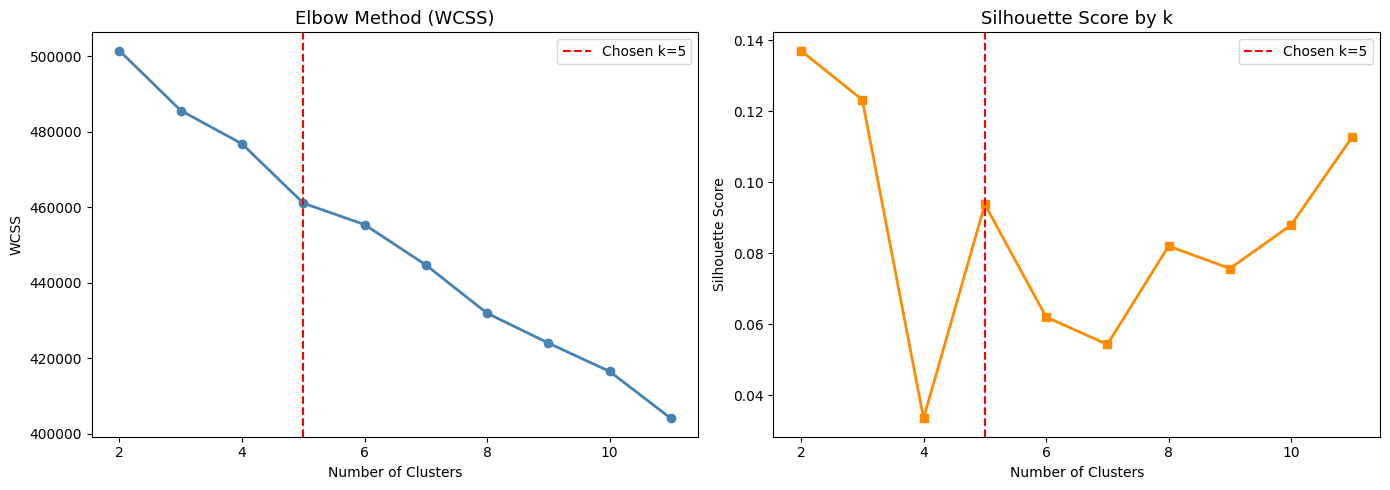

Silhouette score at k=5: 0.0938


In [40]:
wcss = []
silhouette_scores = []
K_range = range(2, 12)

for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++', max_iter=1000, n_init=10, random_state=0)
    km.fit(X)
    wcss.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X, km.labels_, sample_size=2000, random_state=42))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_range, wcss, marker='o', linewidth=2, color='steelblue')
axes[0].axvline(x=5, color='red', linestyle='--', label='Chosen k=5')
axes[0].set_title('Elbow Method (WCSS)', fontsize=13)
axes[0].set_xlabel('Number of Clusters')
axes[0].set_ylabel('WCSS')
axes[0].legend()

axes[1].plot(K_range, silhouette_scores, marker='s', linewidth=2, color='darkorange')
axes[1].axvline(x=5, color='red', linestyle='--', label='Chosen k=5')
axes[1].set_title('Silhouette Score by k', fontsize=13)
axes[1].set_xlabel('Number of Clusters')
axes[1].set_ylabel('Silhouette Score')
axes[1].legend()

plt.tight_layout()
plt.show()
print(f'Silhouette score at k=5: {silhouette_scores[3]:.4f}')

## 5. Fit Final KMeans Model (k=5)

In [41]:
k_final = 5
kmeans = KMeans(n_clusters=k_final, init='k-means++', max_iter=1000, n_init=10, random_state=0)
kmeans.fit(X)
df['cluster'] = kmeans.labels_
print('Cluster sizes:')
print(df['cluster'].value_counts().sort_index())

Cluster sizes:
cluster
0     721
1    1378
2     399
3    4591
4    1718
Name: count, dtype: int64


## 6. PCA Visualization
We reduce the high-dimensional feature space to 2 components for visualization.

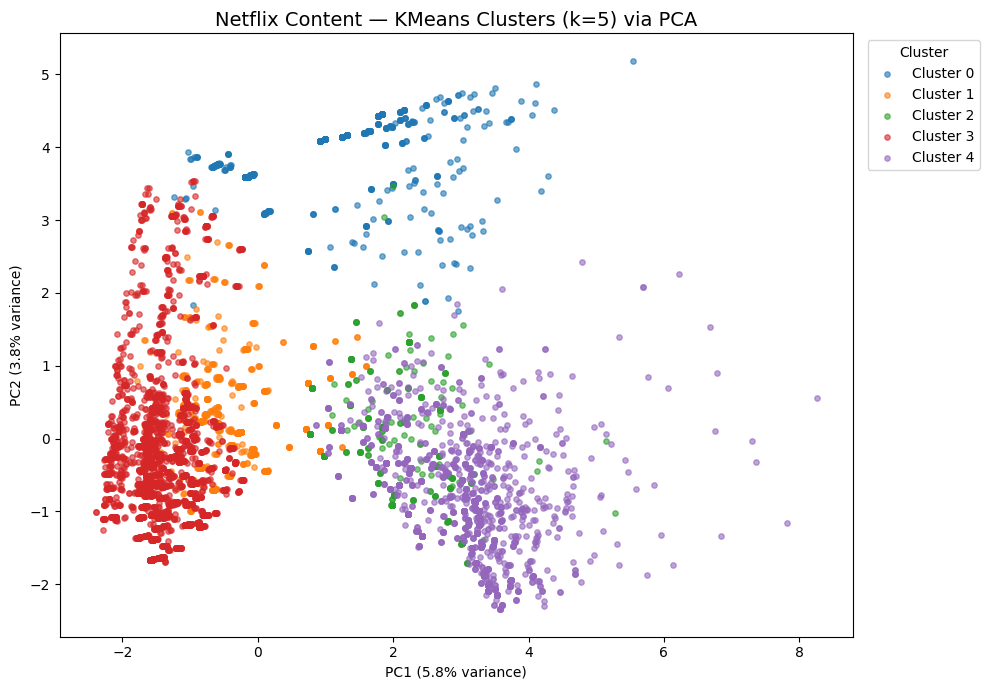

In [42]:
pca = PCA(n_components=2, random_state=42)
pc = pca.fit_transform(X)

plt.figure(figsize=(10, 7))
colors = plt.cm.tab10.colors
for c in range(k_final):
    mask = df['cluster'] == c
    plt.scatter(pc[mask, 0], pc[mask, 1], s=15, alpha=0.6,
                color=colors[c], label=f'Cluster {c}')

plt.title(f'Netflix Content — KMeans Clusters (k={k_final}) via PCA', fontsize=14)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.legend(title='Cluster', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 7. Cluster Profiles
We inspect each cluster's top genres, most common rating, and average duration to interpret what each cluster represents.

In [43]:
exploded = df[['cluster', 'listed_in']].copy()
exploded['listed_in'] = exploded['listed_in'].str.split(', ')
exploded = exploded.explode('listed_in')

top_genres = (exploded[exploded['listed_in'].notna() & (exploded['listed_in'] != '')]
              .groupby(['cluster', 'listed_in'])
              .size()
              .rename('count')
              .reset_index()
              .sort_values(['cluster', 'count'], ascending=[True, False]))

cluster_labels = {}
print('=== Cluster Profiles ===')
for c in sorted(df['cluster'].unique()):
    top5 = top_genres[top_genres['cluster'] == c].head(5)
    top_rating = df.loc[df['cluster'] == c, 'rating'].mode()
    avg_dur = df.loc[df['cluster'] == c, 'duration_minutes'].mean()
    top_genre_name = top5.iloc[0]['listed_in'] if not top5.empty else 'Mixed'
    cluster_labels[c] = top_genre_name

    print(f'\nCluster {c} — "{top_genre_name}" dominant')
    print(f'  Avg duration : {avg_dur:.0f} min')
    print(f'  Top rating   : {top_rating.iloc[0] if len(top_rating) else "N/A"}')
    print(f'  Top genres   : {chr(44)+chr(32)}'.join(top5['listed_in'].tolist()))

df['cluster_label'] = df['cluster'].map(cluster_labels)

=== Cluster Profiles ===

Cluster 0 — "Kids' TV" dominant
  Avg duration : 577 min
  Top rating   : TV-Y7
Kids' TV  Top genres   : , Children & Family Movies  Top genres   : , TV Comedies  Top genres   : , Comedies  Top genres   : , British TV Shows

Cluster 1 — "Documentaries" dominant
  Avg duration : 116 min
  Top rating   : TV-MA
Documentaries  Top genres   : , Stand-Up Comedy  Top genres   : , International Movies  Top genres   : , Music & Musicals  Top genres   : , Sports Movies

Cluster 2 — "Docuseries" dominant
  Avg duration : 600 min
  Top rating   : TV-MA
Docuseries  Top genres   : , International TV Shows  Top genres   : , Crime TV Shows  Top genres   : , Science & Nature TV  Top genres   : , British TV Shows

Cluster 3 — "International Movies" dominant
  Avg duration : 108 min
  Top rating   : TV-MA
International Movies  Top genres   : , Dramas  Top genres   : , Comedies  Top genres   : , Action & Adventure  Top genres   : , Independent Movies

Cluster 4 — "International T

## 8. Recommendation Engine
Given any Netflix title, this finds the most similar content **within the same cluster** using **cosine similarity**.

In [44]:
def recommend(title: str, n: int = 10) -> pd.DataFrame:
    """
    Given a Netflix title, return the n most similar titles
    within the same KMeans cluster using cosine similarity.
    """
    match = df[df['title'].str.lower() == title.strip().lower()]

    if match.empty:
        match = df[df['title'].str.lower().str.contains(title.strip().lower(), na=False)]
        if match.empty:
            print(f"'{title}' not found in the dataset. Try a different title.")
            return pd.DataFrame()
        print(f"Exact match not found. Closest match: '{match.iloc[0]['title']}'")

    idx = match.index[0]
    cluster_id = df.loc[idx, 'cluster']
    title_found = df.loc[idx, 'title']
    print(f"\n '{title_found}' → Cluster {cluster_id} ({cluster_labels[cluster_id]})\n")

    cluster_mask = df['cluster'] == cluster_id
    cluster_indices = df[cluster_mask].index
    cluster_X_scaled = scaler.transform(features.loc[cluster_indices].values)
    input_vec = scaler.transform(features.loc[[idx]].values)

    sims = cosine_similarity(input_vec, cluster_X_scaled)[0]
    sim_series = pd.Series(sims, index=cluster_indices).drop(idx, errors='ignore')
    top_indices = sim_series.nlargest(n).index

    results = df.loc[top_indices, ['title', 'type', 'listed_in', 'rating', 'duration', 'cluster_label']].copy()
    results['similarity'] = sim_series[top_indices].round(4).values
    results = results.reset_index(drop=True)
    results.index += 1
    return results

## 9. Try the Recommender
Edit the form below and run the cell to get recommendations!

In [45]:
#@title Netflix Recommender
#@markdown Type a movie or show title and run this cell

title_input = 'Stranger Things' #@param {type:"string"}
num_recommendations = 10 #@param {type:"slider", min:3, max:20, step:1}

results = recommend(title_input, num_recommendations)
if not results.empty:
    display(results)


 'Stranger Things' → Cluster 4 (International TV Shows)



,title,type,listed_in,rating,duration,cluster_label,similarity
1,Chilling Adventures of Sabrina,TV Show,"TV Horror, TV Mysteries, TV Sci-Fi & Fantasy",TV-14,4 Seasons,International TV Shows,0.9988
2,Nightflyers,TV Show,"TV Horror, TV Mysteries, TV Sci-Fi & Fantasy",TV-MA,1 Season,International TV Shows,0.9797
3,Helix,TV Show,"TV Horror, TV Mysteries, TV Sci-Fi & Fantasy",TV-MA,1 Season,International TV Shows,0.9797
4,The Mystic River,TV Show,"International TV Shows, TV Horror, TV Sci-Fi &...",TV-14,1 Season,International TV Shows,0.8263
5,The Guest,TV Show,"International TV Shows, TV Horror, TV Mysteries",TV-14,1 Season,International TV Shows,0.7975
6,Anjaan: Special Crimes Unit,TV Show,"International TV Shows, TV Horror, TV Mysteries",TV-14,1 Season,International TV Shows,0.7975
7,ThirTEEN Terrors,TV Show,"International TV Shows, TV Horror, TV Mysteries",TV-14,1 Season,International TV Shows,0.7975
8,The Originals,TV Show,"TV Dramas, TV Horror, TV Mysteries",TV-14,5 Seasons,International TV Shows,0.7904
9,Lost Girl,TV Show,"TV Dramas, TV Horror, TV Mysteries",TV-14,5 Seasons,International TV Shows,0.7904
10,Goedam,TV Show,"International TV Shows, TV Horror, TV Mysteries",TV-MA,1 Season,International TV Shows,0.7789
